In [66]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

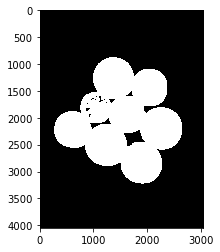

In [ ]:
path = "C:/Users/monukoru/Downloads/image processing python/DATA/coins_on_white.jpg"
# simple thresholding of the image 
img = cv2.imread(path)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_gray = cv2.medianBlur(img_gray, ksize=15)
ret1, img_thresh = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
sure_bg = cv2.dilate(img_thresh, np.ones((19,19), dtype=np.uint8), iterations=2)

plt.imshow(sure_bg, cmap='gray')

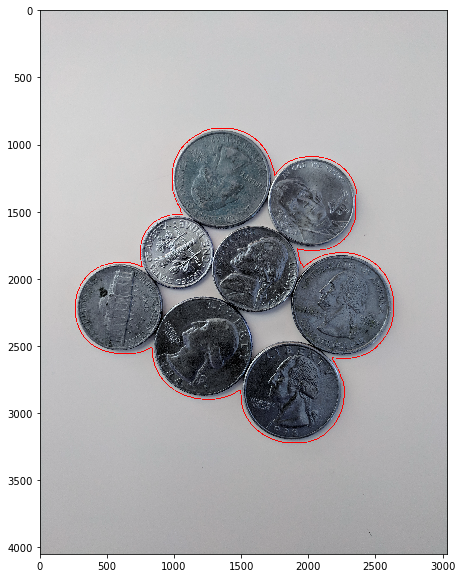

In [68]:
# here we will have the contours 
_, contour, __ = cv2.findContours(sure_bg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
c= cv2.drawContours(img, contour, -1, (255,0,0), thickness=5)
plt.figure(figsize=(10,10))
plt.imshow(c)

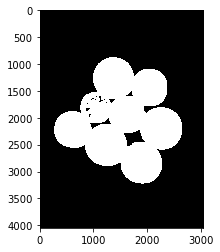

In [69]:
#now we will image transform
dist_transform = cv2.distanceTransform(sure_bg, cv2.DIST_L2, 5)
plt.imshow(sure_bg, cmap='gray')

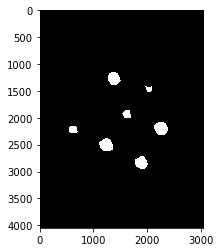

In [70]:
# here we will set the seed or you can say sure foreground
ret2, sure_fg = cv2.threshold(dist_transform, 0.7*dist_transform.max(), 255, cv2.THRESH_BINARY)
plt.imshow(sure_fg,cmap='gray')

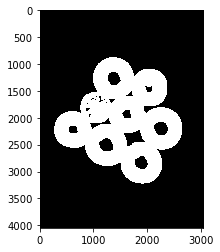

In [71]:
#here we will seprate bg and fg from unknown
sure_fg = cv2.convertScaleAbs(sure_fg)
unknown = sure_bg-sure_fg
plt.imshow(unknown, cmap='gray')

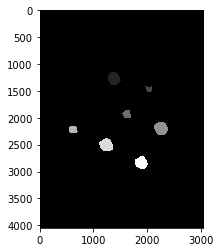

In [74]:
# we will use this function so that it sets the objects differently
ret3, seed = cv2.connectedComponents(sure_fg)
plt.imshow(seed, cmap='gray')


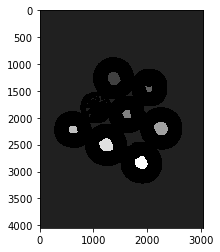

In [ ]:
# now we don't have to keep the background 0 we will set it one like wise. here we ahve manupulated the seed 
seed = seed+1
seed[unknown ==255] = 0
plt.imshow(seed, cmap='gray')

10


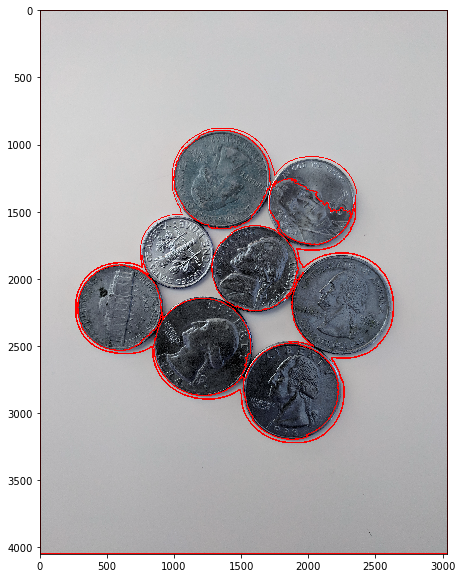

In [89]:
seed = cv2.watershed(img, seed)

ret, contours, hie = cv2.findContours(seed, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

m = cv2.drawContours(img, contours, -1, (255,0,0), thickness=5)

print(len(contours))
plt.figure(figsize=(10,10))
plt.imshow(m)